# DeepFake CNN Architecture

## Step 0: Import Required Libraries We import all libraries required for image processing, ELA, deep learning, and evaluation.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageChops, ImageEnhance

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix

import json

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Step 1: Dataset Directory Structure Using predefined train / valid / test folders


In [3]:
BASE_DIR = "E:/Projects/DeepFake/real-vs-fake"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

## Step 2: Error Level Analysis (ELA)

ELA highlights compression inconsistencies in JPEG images.
These inconsistencies are strong indicators of image manipulation.


In [4]:
def convert_to_ela_image(image_path, quality=95):
    original = Image.open(image_path).convert("RGB")

    temp_path = "temp_ela.jpg"
    original.save(temp_path, "JPEG", quality=quality)

    compressed = Image.open(temp_path)
    diff = ImageChops.difference(original, compressed)

    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    scale = 255.0 / max_diff if max_diff != 0 else 1

    diff = ImageEnhance.Brightness(diff).enhance(scale)
    diff = diff.resize(IMAGE_SIZE)

    return np.array(diff, dtype=np.float32) / 255.0

## Step 3: Load Images from Train / Validation / Test Folders
Labels:
- real → 0
- fake → 1

In [5]:
class ELADataset(Dataset):
    def __init__(self, folder_path):
        self.samples = []
        for label, cls in enumerate(["real", "fake"]):
            class_dir = os.path.join(folder_path, cls)
            for file in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        ela = convert_to_ela_image(img_path)
        ela = torch.tensor(ela).permute(2, 0, 1)  # HWC → CHW
        return ela, label

## Step 4: Split Dataset
We split data into training, validation, and testing sets.


In [6]:
train_loader = DataLoader(ELADataset(TRAIN_DIR), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ELADataset(VAL_DIR), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ELADataset(TEST_DIR), batch_size=BATCH_SIZE, shuffle=False)

## Step 5: Proposed CNN Architecture

Input: 128×128×3 ELA image
- Conv (32, 5×5) + MaxPool
- Conv (64, 3×3) + MaxPool
- Conv (128, 3×3) + MaxPool
- Dense (128)
- Output (Softmax)


In [7]:
import torch
import torch.nn as nn

class DeepFakeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self._to_linear = None
        self._get_flatten_size()

        # 🔥 DROPOUT ADDED HERE
        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),   # <-- KEY LINE
            nn.Linear(128, 2)
        )

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 128, 128)
            x = self.features(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [8]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


## Step 6: Train CNN Model
We train the CNN on ELA images.


In [9]:
model = DeepFakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [10]:
early_stopping = EarlyStopping(patience=3)

for epoch in range(1, 21):
    model.train()
    train_correct, train_total, train_loss = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == y).sum().item()
        train_total += y.size(0)

    train_acc = train_correct / train_total

    # 🔍 VALIDATION
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)

    print(f"Epoch [{epoch}/20] | Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}, Train Loss: {train_loss/len(train_loader):.4f}")

    # 🔥 EARLY STOPPING CHECK
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("🛑 Early stopping triggered")
        break


Epoch [1/20] | Train Acc: 0.6622, Val Acc: 0.7144, Val Loss: 0.5642, Train Loss: 0.6122
Epoch [2/20] | Train Acc: 0.7236, Val Acc: 0.7482, Val Loss: 0.5164, Train Loss: 0.5470
Epoch [3/20] | Train Acc: 0.7508, Val Acc: 0.7636, Val Loss: 0.4914, Train Loss: 0.5108
Epoch [4/20] | Train Acc: 0.7680, Val Acc: 0.7790, Val Loss: 0.4678, Train Loss: 0.4865
Epoch [5/20] | Train Acc: 0.7818, Val Acc: 0.7815, Val Loss: 0.4633, Train Loss: 0.4641
Epoch [6/20] | Train Acc: 0.7925, Val Acc: 0.7925, Val Loss: 0.4438, Train Loss: 0.4448
Epoch [7/20] | Train Acc: 0.8048, Val Acc: 0.8015, Val Loss: 0.4328, Train Loss: 0.4251
Epoch [8/20] | Train Acc: 0.8128, Val Acc: 0.8032, Val Loss: 0.4277, Train Loss: 0.4098
Epoch [9/20] | Train Acc: 0.8238, Val Acc: 0.8052, Val Loss: 0.4210, Train Loss: 0.3899
Epoch [10/20] | Train Acc: 0.8332, Val Acc: 0.7973, Val Loss: 0.4370, Train Loss: 0.3718
Epoch [11/20] | Train Acc: 0.8427, Val Acc: 0.8107, Val Loss: 0.4226, Train Loss: 0.3525
Epoch [12/20] | Train Acc: 0.8

In [11]:
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)

        probs = torch.softmax(outputs, dim=1)[:, 1]  # FAKE class prob
        y_scores.extend(probs.cpu().numpy())
        y_true.extend(y.numpy())


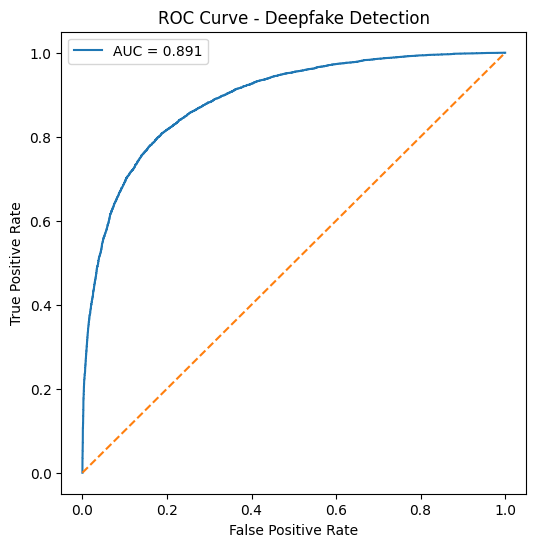

ROC-AUC: 0.8906112300000001


In [12]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Deepfake Detection")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc)


## Step 7: Plot Training and Validation Curves


In [14]:
# epochs = range(1, EPOCHS + 1)

# plt.figure(figsize=(12,4))

# plt.subplot(1,2,1)
# plt.plot(epochs, train_accs, label="Train Accuracy")
# plt.plot(epochs, val_accs, label="Validation Accuracy")
# plt.title("Accuracy Curve")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(epochs, train_losses, label="Train Loss")
# plt.plot(epochs, val_losses, label="Validation Loss")
# plt.title("Loss Curve")
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.legend()

# plt.show()

## Step 8: Evaluate Model on Test Set


In [15]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81     10000
           1       0.82      0.80      0.81     10000

    accuracy                           0.81     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.81      0.81      0.81     20000

[[8197 1803]
 [2004 7996]]


## Step 9: Predict on New Image


In [16]:
def predict_image(image_path):
    model.eval()
    ela = convert_to_ela_image(image_path)
    ela = torch.tensor(ela).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(ela)
        pred = torch.argmax(output, dim=1).item()

    return "FAKE" if pred == 1 else "REAL"

In [17]:
result_fake = predict_image("E:/Projects/DeepFake/real-vs-fake/test/fake/0SD99OI7CY.jpg")
print("The image is predicted to be:", result_fake)

The image is predicted to be: FAKE


In [18]:
result_real = predict_image("E:/Projects/DeepFake/real-vs-fake/test/real/00693.jpg")
print("The image is predicted to be:", result_real)

The image is predicted to be: REAL


## Save Model And Configuration

In [19]:
torch.save(model.state_dict(), "E:/Projects/DeepFake/Models/deepfake_cnn_2.pth")

In [20]:
config = {
    "model_name": "DeepfakeCNN_ELA",
    "framework": "pytorch",
    "input_size": [128, 128, 3],
    "ela_quality": 95,
    "normalization": "divide_by_255",
    "class_mapping": {
        "0": "REAL",
        "1": "FAKE"
    },
    "num_classes": 2,
    "author": "Urvi",
    "version": "1.0"
}

with open("E:/Projects/DeepFake/Models/configuration/config_cnn_2.json", "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved: config_cnn_2.json")

Configuration saved: config_cnn_2.json


##  Load The Model

In [21]:
import json

def load_config(config_path="E:/Projects/DeepFake/Models/configuration/config_cnn_2.json"):
    with open(config_path, "r") as f:
        config = json.load(f)
    return config

In [25]:
import torch
import torch.nn as nn

class DeepFakeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self._to_linear = None
        self._get_flatten_size()

        # 🔥 DROPOUT ADDED HERE
        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),   # <-- KEY LINE
            nn.Linear(128, 2)
        )

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 128, 128)
            x = self.features(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [26]:
import torch
import json

def load_model(
    model_path="E:/Projects/DeepFake/Models/deepfake_cnn_2.pth",
    config_path="E:/Projects/DeepFake/Models/configuration/config_cnn_2.json"
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load config
    with open(config_path, "r") as f:
        config = json.load(f)

    # Build model
    model = DeepFakeCNN().to(device)

    # Load weights
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)

    model.eval()

    return model, config, device


In [27]:
model, config, device = load_model()

print("✅ Model loaded successfully")
print("Device:", device)

✅ Model loaded successfully
Device: cuda


In [28]:
def predict_image(image_path):
    model.eval()
    ela = convert_to_ela_image(image_path)
    ela = torch.tensor(ela).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(ela)
        pred = torch.argmax(output, dim=1).item()

    return "FAKE" if pred == 1 else "REAL"

In [29]:
result_fake = predict_image("E:/Projects/DeepFake/real-vs-fake/test/fake/0SD99OI7CY.jpg")
print("The image is predicted to be:", result_fake)

The image is predicted to be: FAKE


In [45]:
resulttt = predict_image("E:/Projects/DeepFake/real-vs-fake/test/fake/0AEIDNSBKD.jpg")
print("The image is predicted to be:", resulttt)

The image is predicted to be: FAKE


In [47]:
resultt = predict_image("E:/Projects/DeepFake/13.jpeg")
print("The image is predicted to be:", resultt)

The image is predicted to be: REAL
